## Resumen de la revisión v1 <a class="tocSkip"></a>

----

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Hallazgos**
- El dataset contiene 40,000 registros y no presenta valores ausentes en ninguna de sus columnas.
- Respecto a los tipos de datos, se identificó que la columna date está almacenada como object, por lo que debe convertirse a formato datetime para facilitar análisis temporales.
- El resto de las variables presentan tipos de datos consistentes con su naturaleza y no requieren modificaciones iniciales.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
print("Usuarios únicos:", df['user_id'].nunique())

Usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
columnas_categoricas = [
    'landing',
    'region',
    'dispositivo',
    'traffic_source',
    'user_type'
]

for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


Conteo de categorías:

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


**Hallazgos**
- Se revisaron las variables categóricas del dataset (landing, region, dispositivo, traffic_source y user_type) para verificar la presencia de categorías inesperadas o errores de escritura.
- No se identificaron valores nulos ni inconsistencias evidentes en las categorías observadas.
- En particular, la variable landing, que define los grupos del experimento A/B, contiene únicamente las categorías esperadas.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']#completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [12]:
pd.DataFrame({
    'Grupo A': gasto_A.describe(),
    'Grupo B': gasto_B.describe()
})

,Grupo A,Grupo B
count,2512.000000,3194.00000
mean,61.086572,68.74536
std,28.875470,32.00102
min,12.120000,12.98000
25%,40.612500,45.21000
50%,55.840000,62.57000
75%,74.837500,84.27750
max,303.680000,249.99000


### Prueba t-test

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de la página A es igual al gasto promedio de la página B ( μ_A = μ_B)
- **Hipótesis alternativa (H₁):** El gasto promedio de la página A es diferente entre el gasto promedio de la página B (μ_A ≠ μ_B)

In [13]:
ttest_ind(gasto_A, gasto_B)

Ttest_indResult(statistic=-9.36563589591332, pvalue=1.0635288333792346e-20)

In [14]:
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

In [15]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Los resultados indican que existe evidencia estadísticamente significativa de una diferencia en el gasto promedio de los usuarios convertidos entre las páginas A y B. En promedio, los usuarios que convirtieron en la página B gastaron aproximadamente 7.66 unidades monetarias más que los usuarios de la página A.

Desde una perspectiva de negocio, esto sugiere que la página B no solo logra conversiones, sino que además atrae clientes con un mayor valor económico promedio, lo que podría traducirse en mayores ingresos para la empresa. Sin embargo, antes de implementar definitivamente la página B, sería recomendable evaluar también el tamaño del efecto, el impacto total en ingresos y la consistencia del resultado en diferentes segmentos de usuarios.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo. 
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la decisión de compra. 

In [16]:
# Número de usuarios convertidos por página
conversiones= df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales= df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
# Aplicar prueba
z_stat, p_value=proportions_ztest(conversiones, totales)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [18]:
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. 

**Interpretación de negocio:**  
Los resultados muestran evidencia estadísticamente significativa de una diferencia en las tasas de conversión entre las páginas A y B. La página B presenta una tasa de conversión de 15.96%, superior a la de la página A, que alcanza 12.57%.

Desde una perspectiva de negocio, estos resultados sugieren que la página B es más efectiva para incentivar a los usuarios a completar la acción objetivo (conversión). Esto podría indicar que su diseño, contenido o experiencia de usuario resulta más atractiva o persuasiva para los visitantes. Por lo tanto, implementar la página B podría contribuir a incrementar el número de conversiones y generar mejores resultados para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables traffic_source y converted (son independientes)
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las variables traffic_source y converted (no son independientes).

In [19]:
df['converted'].value_counts()

0    34294
1     5706
Name: converted, dtype: int64

In [20]:
df[['converted', 'traffic_source']].value_counts()

converted  traffic_source
0          Organic           15507
           Ads               10176
           Email              5205
           Referral           3406
1          Organic            2480
           Ads                1759
           Email               918
           Referral            549
dtype: int64

In [21]:
#tabla de contingencia 
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [22]:
# Aplicar prueba
chi2_contingency(tabla)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [23]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Los resultados de la prueba chi-cuadrado (p = 0.034) indican que existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión de los usuarios. Esto significa que la probabilidad de conversión no es la misma para todos los canales de adquisición, por lo que la fuente de tráfico influye en el desempeño del experimento.

En términos de negocio, aunque Organic genera la mayor cantidad absoluta de conversiones (2,480) debido a su alto volumen de usuarios, las fuentes Email (14.99%) y Ads (14.74%) presentan las tasas de conversión más altas. Esto sugiere que estos canales son más eficientes para convertir usuarios en clientes, mientras que Organic continúa siendo una fuente clave por su capacidad para atraer un gran volumen de tráfico y conversiones totales.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables user_type y converted (son independientes)
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las variables user_type y converted (no son independientes).

In [24]:
df['converted'].value_counts()

0    34294
1     5706
Name: converted, dtype: int64

In [25]:
df[['user_type', 'converted']].value_counts()

user_type   converted
Nuevo       0            22295
Recurrente  0            11999
Nuevo       1             3738
Recurrente  1             1968
dtype: int64

In [26]:
#tabla de contingencia 
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [27]:
# Aplicar prueba
chi2_contingency(tabla)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [28]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

Decisión:
No se rechaza la hipótesis nula.

Interpretación de negocio:
Los resultados de la prueba chi-cuadrado (χ² = 0.513, p = 0.474) indican que no existe evidencia estadísticamente significativa para afirmar que el tipo de usuario (Nuevo o Recurrente) influya en la probabilidad de conversión. Aunque en términos absolutos los usuarios nuevos registran más conversiones (3,738 frente a 1,968), esto se debe principalmente a que también representan un mayor volumen de usuarios dentro del dataset.

Al analizar las tasas de conversión, los usuarios nuevos convierten aproximadamente un 14.36% (3,738 de 26,033), mientras que los usuarios recurrentes convierten cerca de un 14.09% (1,968 de 13,967). La diferencia es muy pequeña y estadísticamente no significativa, por lo que desde una perspectiva de negocio ambos segmentos presentan un comportamiento de conversión similar. Esto sugiere que no sería necesario diseñar estrategias diferenciadas de conversión únicamente en función de si el usuario es nuevo o recurrente.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [29]:
#tabla de contingencia normalizada
tabla = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


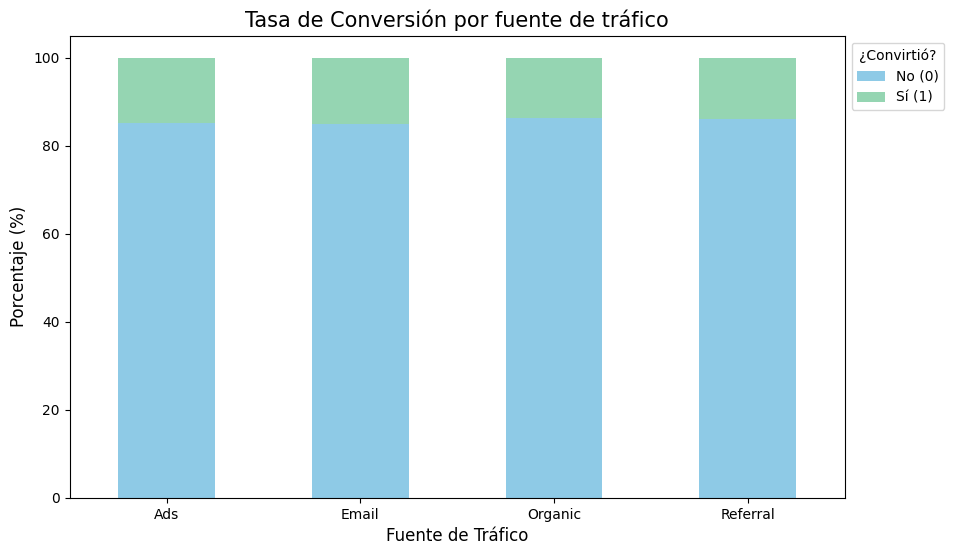

In [30]:
# Gráfico de barras apiladas
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de Tráfico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

**Hallazgos relevantes**

1. Email es el canal con la mayor tasa de conversión

La fuente Email presenta la tasa de conversión más alta (14.99%), superando ligeramente a Ads (14.74%), Organic (13.79%) y Referral (13.88%).

Insight de negocio:
Los usuarios adquiridos mediante campañas de email parecen tener una mayor propensión a completar la conversión, lo que sugiere que este canal atrae tráfico de mayor calidad o usuarios más interesados en la oferta.

2. Organic genera menos conversiones proporcionales

Aunque Organic suele aportar un volumen importante de tráfico, su tasa de conversión (13.79%) es la más baja entre las fuentes analizadas.

Insight de negocio:
Existe una oportunidad para optimizar la experiencia de los usuarios provenientes de tráfico orgánico y aumentar su probabilidad de conversión.

3. Las diferencias entre canales son relativamente pequeñas

Las tasas de conversión oscilan entre 13.79% y 14.99%, una diferencia aproximada de 1.2 puntos porcentuales.

Insight de negocio:
Aunque estadísticamente existen diferencias entre canales (según la prueba chi-cuadrado realizada previamente), el impacto práctico es moderado. Por ello, las decisiones de inversión no deberían basarse únicamente en la tasa de conversión, sino también en el volumen de tráfico y el costo de adquisición de cada canal.

In [31]:
#tabla de contingencia 
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


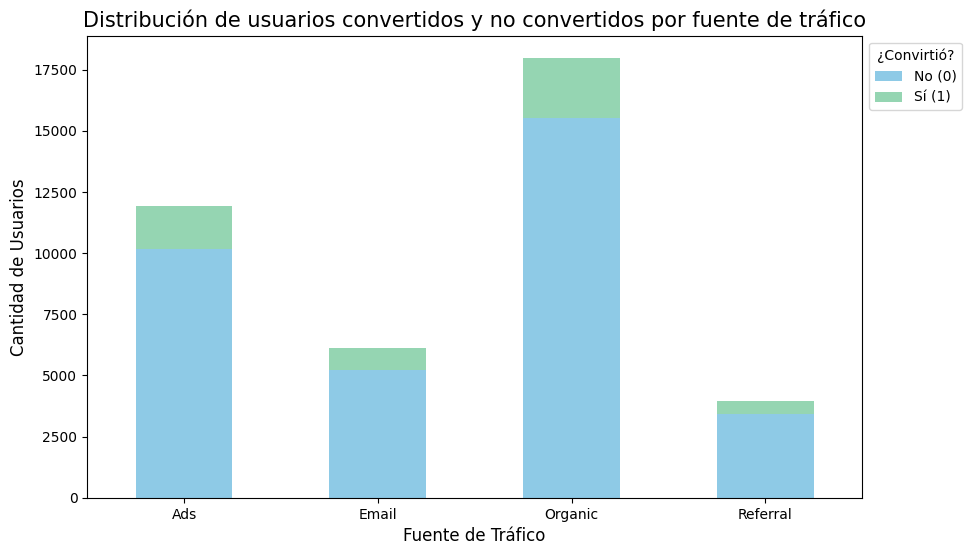

In [32]:
# Gráfico de barras apiladas
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Distribución de usuarios convertidos y no convertidos por fuente de tráfico', fontsize=15)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.xlabel('Fuente de Tráfico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

**Hallazgos relevantes**

El gráfico muestra la distribución de usuarios convertidos y no convertidos según la fuente de tráfico. Se observa que Organic aporta la mayor cantidad de usuarios y también el mayor número absoluto de conversiones (2,480), seguido de Ads (1,759), Email (918) y Referral (549). Sin embargo, en todas las fuentes predominan los usuarios que no convierten, lo que indica que la conversión es un evento relativamente poco frecuente.

Al comparar las proporciones, Email y Ads presentan una mayor participación de usuarios convertidos respecto a su volumen total de tráfico, mientras que Organic genera más conversiones principalmente por la gran cantidad de usuarios que atrae. Esto sugiere que la fuente de tráfico puede influir en la probabilidad de conversión y que algunos canales son más eficientes que otros para captar usuarios con intención de convertirse.

### Relación entre el tipo de usuario y la conversión

In [33]:
#tabla de contingencia 
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


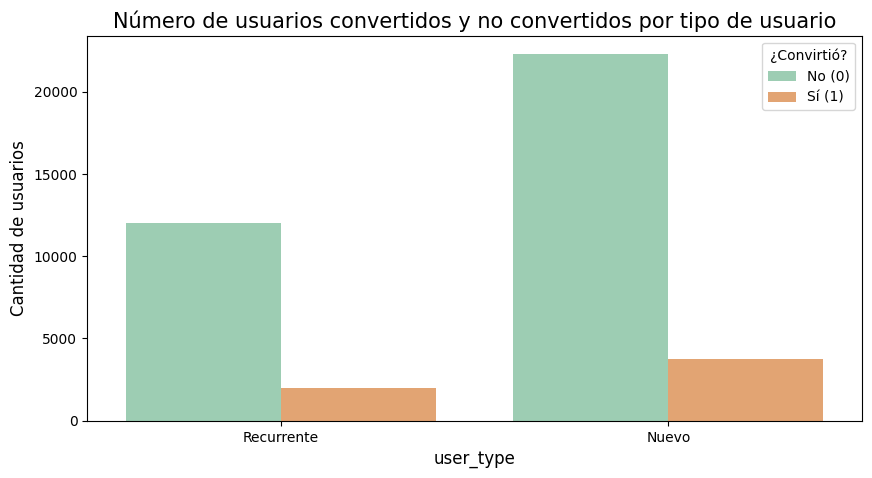

In [34]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Número de usuarios convertidos y no convertidos por tipo de usuario', fontsize=15)
plt.xlabel('user_type', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

**Hallazgos relevantes**

-Hallazgo 1: Los usuarios nuevos generan más conversiones en términos absolutos

Los usuarios nuevos registran 3,738 conversiones, mientras que los usuarios recurrentes registran 1,968 conversiones. Esto significa que aproximadamente el 65.5% de todas las conversiones provienen de usuarios nuevos.

-Hallazgo 2: La tasa de conversión es muy similar entre ambos grupos

Calculando las tasas de conversión:

Usuarios nuevos: 3,738 / 26,033 = 14.36%
Usuarios recurrentes: 1,968 / 13,967 = 14.09%

La diferencia es de apenas 0.27 puntos porcentuales.

-Hallazgo 3: Predominan los usuarios que no convierten

En ambos segmentos, la mayoría de los usuarios no realiza la conversión:

Nuevos: 85.64% no convierten.
Recurrentes: 85.91% no convierten.

En otras palabras, los usuarios nuevos generan un mayor número de conversiones (3,738 frente a 1,968), aportando aproximadamente dos tercios de las conversiones totales. Sin embargo, al analizar las tasas de conversión, ambos segmentos presentan resultados muy similares (14.36% para usuarios nuevos y 14.09% para recurrentes), lo que sugiere que el tipo de usuario no tiene un impacto relevante en la probabilidad de conversión. Además, en ambos grupos más del 85% de los usuarios no convierte, lo que representa una oportunidad para mejorar el desempeño general del proceso de conversión.

In [35]:
#tabla de contingencia normalizada
tabla = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


**Hallazgos relevantes-**

-Hallazgo 1: Las tasas de conversión son muy similares

Los usuarios nuevos presentan una tasa de conversión de 14.36%, mientras que los usuarios recurrentes registran una tasa de 14.09%. La diferencia es de apenas 0.27 puntos porcentuales.

-Hallazgo 2: La mayoría de los usuarios no convierte

Más del 85% de los usuarios no completa la conversión, independientemente de si son nuevos o recurrentes.

-Hallazgo 3: No se observan diferencias relevantes a nivel práctico

Aunque los usuarios nuevos convierten ligeramente más que los recurrentes, la diferencia es muy pequeña desde una perspectiva de negocio.

En otras palabras, las tasas de conversión son muy similares entre usuarios nuevos (14.36%) y recurrentes (14.09%), con una diferencia de apenas 0.27 puntos porcentuales. Esto sugiere que el tipo de usuario tiene un impacto limitado en la probabilidad de conversión. Además, en ambos segmentos más del 85% de los usuarios no completa la acción objetivo, lo que indica una oportunidad para optimizar el proceso de conversión y mejorar el rendimiento general del negocio.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---


### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió**:

Se identificó una diferencia estadísticamente significativa en el gasto promedio entre las versiones A y B.
Los usuarios que convirtieron en la página B gastaron en promedio aproximadamente 7.66 unidades monetarias más que los usuarios de la página A.

**Interpretación**:

La página B no solo logra conversiones, sino que además genera un mayor valor económico por cliente convertido, lo que podría traducirse en mayores ingresos para el negocio.

**Tasa de conversión**:

La página B obtuvo una tasa de conversión de 15.96%, mientras que la página A registró 12.57%.
La diferencia fue estadísticamente significativa (p < 0.05), por lo que es poco probable que se deba al azar.

**Interpretación**:

La página B es más efectiva para persuadir a los usuarios a completar la acción objetivo, generando una mayor proporción de conversiones que la página A.

**Segmentación por fuente de tráfico**
Las fuentes Email (14.99%) y Ads (14.74%) presentaron las tasas de conversión más altas.
Aunque Organic tuvo la tasa de conversión más baja (13.79%), generó el mayor número absoluto de conversiones (2,480) gracias a su alto volumen de tráfico.
Aunque Referral aporta el menor volumen de conversiones, su tasa de conversión (13.88%) supera ligeramente a Organic (13.79%). Esto sugiere que las recomendaciones o referencias generan tráfico relativamente cualificado y podrían representar una oportunidad de crecimiento si se implementan programas de referidos o incentivos para recomendaciones.

**Interpretación**:

Los canales Email y Ads son los más eficientes para convertir usuarios, mientras que Organic continúa siendo una fuente estratégica por la cantidad de tráfico y conversiones que aporta. Por su parte, Referral muestra potencial para captar usuarios de calidad y podría fortalecerse mediante estrategias de referidos o programas de recomendación.

**Segmentación por tipo de usuario**
Los usuarios nuevos presentan una tasa de conversión de 14.36%, mientras que los recurrentes registran 14.09%.
La diferencia observada es mínima y no se encontró evidencia estadística suficiente para considerarla significativa.

**Interpretación**:

El comportamiento de conversión es similar entre usuarios nuevos y recurrentes, por lo que el tipo de usuario no parece ser un factor determinante para explicar las conversiones observadas.

Las visualizaciones utilizadas respaldan los resultados estadísticos obtenidos en las pruebas de hipótesis y permiten identificar patrones consistentes en el comportamiento de los usuarios.

**Recomendaciones de negocio**
Implementar la página B como versión principal, ya que supera a la página A tanto en tasa de conversión como en gasto promedio por usuario convertido.
Incrementar y optimizar las inversiones en los canales Email y Ads, debido a que presentan las mayores tasas de conversión.
Mantener estrategias de adquisición orgánica, ya que continúa siendo la principal fuente de conversiones en términos absolutos.
Priorizar pruebas y optimizaciones enfocadas en la experiencia de la página y los canales de adquisición, en lugar de segmentar esfuerzos entre usuarios nuevos y recurrentes, ya que ambos grupos muestran un comportamiento de conversión muy similar.
